# EURUSD Trading Strategy

Processing EURUSD OHLCV data from local files at 1-hour (H1) and 5-minute (M5) intervals

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
import time
import os
import json
import matplotlib.pyplot as plt
import pandas_ta as ta
import numpy as np
import schedule
from tvDatafeed import TvDatafeed, Interval
import re
import logging

In [6]:
import os
import time
import logging
import pandas as pd
from datetime import datetime, timedelta
from tvDatafeed import TvDatafeed, Interval
from concurrent.futures import ThreadPoolExecutor
import configparser
import signal
import sys

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("data_fetcher.log"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

class TradingViewDataFetcher:
    # Constants
    RETRY_ATTEMPTS = 3
    RETRY_DELAY = 5  # seconds
    INTERVALS = {
        'H1': Interval.in_1_hour,
        'M5': Interval.in_5_minute,
        # Add more intervals if needed
    }
    
    # Interval durations in seconds - used for timing calculations
    INTERVAL_DURATIONS = {
        'H1': 3600,  # 1 hour in seconds
        'M5': 300,   # 5 minutes in seconds
    }
    
    def __init__(self, username=None, password=None, data_dir='data'):
        """Initialize the TradingView data fetcher with optional credentials."""
        self.username = username
        self.password = password
        self.data_dir = data_dir
        self.symbol = None
        self.exchange = None
        self.running = False
        self.last_successful_update = {}
        
        # Ensure output directory exists
        os.makedirs(self.data_dir, exist_ok=True)
        
        # Connect to TradingView
        self._connect()
        
    def _connect(self):
        """Establish connection to TradingView with error handling."""
        logger.info("Connecting to TradingView...")
        
        for attempt in range(self.RETRY_ATTEMPTS):
            try:
                if self.username and self.password:
                    self.tv = TvDatafeed(username=self.username, password=self.password)
                    logger.info("Connection established with credentials!")
                else:
                    self.tv = TvDatafeed()
                    logger.info("Connection established without login (some data may be limited)")
                return
            except Exception as e:
                logger.error(f"Connection attempt {attempt+1}/{self.RETRY_ATTEMPTS} failed: {e}")
                if attempt < self.RETRY_ATTEMPTS - 1:
                    time.sleep(self.RETRY_DELAY)
                else:
                    logger.error("Failed to connect to TradingView after multiple attempts")
                    raise
        
    def _get_filepath(self, interval):
        """Get standardized filepath for a given interval."""
        return os.path.join(self.data_dir, f'{self.symbol}_{self.exchange}_{interval}.csv')
        
    def fetch_historical_data(self, symbol, exchange, interval, days_back=7):
        """Fetch historical data for specified interval and days back, excluding incomplete candles."""
        self.symbol = symbol
        self.exchange = exchange
        
        logger.info(f"Fetching historical {interval} data for {symbol} on {exchange}...")
        
        try:
            # Calculate exact timestamps
            end_time = datetime.now()
            start_time = end_time - timedelta(days=days_back)
            
            # Determine how many bars to fetch based on interval
            interval_seconds = 3600 if interval == 'H1' else 300  # 1 hour or 5 minutes
            n_bars = int((end_time - start_time).total_seconds() / interval_seconds) + 30  # Add larger buffer
            
            logger.debug(f"Requesting {n_bars} bars for {interval}")
            
            # Fetch the data
            df = self._fetch_with_retry(symbol, exchange, interval, n_bars)
            
            if df is None or df.empty:
                logger.warning(f"No data returned for {symbol} on {exchange} with interval {interval}")
                return None
                
            # Reset index to make datetime a column and format for CSV
            df = df.reset_index()
            
            # Filter out incomplete candles
            logger.info(f"Filtering out incomplete candles from historical data")
            orig_len = len(df)
            df = df[df['datetime'].apply(lambda x: self.is_candle_complete(interval, x))]
            logger.info(f"Removed {orig_len - len(df)} incomplete candles from historical data")
            
            if df.empty:
                logger.warning("All fetched historical candles are incomplete. Try increasing days_back.")
                return None
            
            # Save to CSV
            filepath = self._get_filepath(interval)
            df.to_csv(filepath, index=False)
            logger.info(f"Saved historical data to {filepath} ({len(df)} complete candles)")
            
            # Log the time range of the data
            start_date = df['datetime'].min()
            end_date = df['datetime'].max()
            logger.info(f"Historical data range: {start_date} to {end_date}")
            
            return df
            
        except Exception as e:
            logger.error(f"Error fetching historical data: {e}")
            return None
    
    def _fetch_with_retry(self, symbol, exchange, interval, n_bars):
        """Fetch data with retry logic."""
        for attempt in range(self.RETRY_ATTEMPTS):
            try:
                return self.tv.get_hist(
                    symbol=symbol,
                    exchange=exchange,
                    interval=self.INTERVALS[interval],
                    n_bars=n_bars
                )
            except Exception as e:
                logger.error(f"Fetch attempt {attempt+1}/{self.RETRY_ATTEMPTS} failed: {e}")
                if attempt < self.RETRY_ATTEMPTS - 1:
                    logger.info(f"Retrying in {self.RETRY_DELAY} seconds...")
                    time.sleep(self.RETRY_DELAY)
        
        logger.error(f"Failed to fetch data after {self.RETRY_ATTEMPTS} attempts")
        return None
    
    def is_candle_complete(self, interval, datetime_val):
        """Check if the current candle is complete."""
        try:
            current_time = datetime.now()
            
            # Convert to datetime if string
            if isinstance(datetime_val, str):
                candle_time = pd.to_datetime(datetime_val)
            else:
                candle_time = datetime_val
                
            # Remove timezone info if present
            if hasattr(candle_time, 'tz_localize') and candle_time.tzinfo is not None:
                candle_time = candle_time.tz_localize(None)
            
            # Calculate when the next candle should start
            if interval == 'H1':
                next_candle = candle_time + pd.Timedelta(hours=1)
            elif interval == 'M5':
                next_candle = candle_time + pd.Timedelta(minutes=5)
            else:
                logger.warning(f"Unknown interval: {interval}")
                return False

            # Check if candle is complete - strictly require start of next candle
            is_complete = current_time >= next_candle
            
            # Add a small buffer (1% of interval) to ensure candle is really complete
            if interval == 'H1':
                buffer = pd.Timedelta(seconds=36)  # 1% of hour
            elif interval == 'M5':
                buffer = pd.Timedelta(seconds=3)   # 1% of 5 minutes
                
            is_complete_with_buffer = current_time >= (next_candle + buffer)
            
            if is_complete and not is_complete_with_buffer:
                logger.debug(f"Candle at {candle_time} is technically complete but still in buffer period")
                return False  # Still in buffer period, consider incomplete
                
            return is_complete
            
        except Exception as e:
            logger.error(f"Error checking if candle is complete: {e}")
            return False

    def update_data(self, symbol, exchange, interval):
        """Update data for the specified interval, ignoring currently open candles."""
        if not self.symbol:
            self.symbol = symbol
            self.exchange = exchange
            
        logger.debug(f"Updating {interval} data for {symbol}...")

        try:
            # Get the latest data with extra bars for better context
            n_bars = 30 if interval == 'M5' else 20  # More bars for shorter timeframes
            latest_df = self._fetch_with_retry(symbol, exchange, interval, n_bars)
            
            if latest_df is None or latest_df.empty:
                logger.warning(f"No data returned when updating {interval} data")
                return None

            latest_df = latest_df.reset_index()
            
            # Log the most recent candle time before filtering
            if not latest_df.empty:
                most_recent = latest_df['datetime'].max()
                logger.debug(f"Most recent {interval} candle before filtering: {most_recent}")
            
            # Strictly filter out incomplete candles
            complete_df = latest_df[latest_df['datetime'].apply(
                lambda x: self.is_candle_complete(interval, x)
            )]

            if complete_df.empty:
                logger.debug(f"No complete candles available for {interval} - current candle still in progress")
                return None
                
            # Log the most recent complete candle
            most_recent_complete = complete_df['datetime'].max()
            logger.debug(f"Most recent complete {interval} candle: {most_recent_complete}")
            
            # Calculate difference from current time
            time_diff = datetime.now() - pd.to_datetime(most_recent_complete)
            logger.debug(f"Current complete candle is {time_diff} old")

            # Process file update
            filepath = self._get_filepath(interval)
            
            if os.path.exists(filepath):
                # Update existing file
                existing_df = pd.read_csv(filepath)
                existing_df['datetime'] = pd.to_datetime(existing_df['datetime'])

                # Check for new data - using strict equality check
                existing_datetimes = set(existing_df['datetime'])
                new_data = complete_df[~complete_df['datetime'].isin(existing_datetimes)]
                
                if not new_data.empty:
                    # Log details about new data
                    new_dates = sorted(new_data['datetime'].dt.strftime('%Y-%m-%d %H:%M').tolist())
                    logger.info(f"Found {len(new_data)} new {interval} candles: {new_dates}")
                    
                    # Remove any overlapping data and append new complete data
                    # Use pandas merge to handle this efficiently
                    combined_df = pd.concat([
                        existing_df[~existing_df['datetime'].isin(complete_df['datetime'])], 
                        complete_df
                    ])
                    # Sort to ensure chronological order
                    combined_df = combined_df.sort_values('datetime')
                    
                    # Save updated data
                    combined_df.to_csv(filepath, index=False)
                    logger.info(f"Updated {interval} data with {len(new_data)} new complete candles")
                    
                    # Update last successful time
                    self.last_successful_update[interval] = datetime.now()
                    return combined_df
                else:
                    logger.debug(f"No new complete {interval} candles to add")
                    return existing_df
            else:
                # Create new file with only complete candles
                complete_df.to_csv(filepath, index=False)
                logger.info(f"Created new file {filepath} with {len(complete_df)} complete candles")
                
                # Update last successful time
                self.last_successful_update[interval] = datetime.now()
                return complete_df
                
        except Exception as e:
            logger.error(f"Error updating {interval} data: {e}")
            return None
    
    def _calculate_next_check_time(self, interval):
        """Calculate the next time to check for a completed candle based on interval."""
        current_time = datetime.now()
        
        if interval == 'H1':
            # For hourly candles, check at start of next hour
            next_hour = current_time.replace(minute=0, second=0, microsecond=0) + timedelta(hours=1)
            # Add a small buffer to ensure the candle is complete
            return next_hour + timedelta(seconds=10)
        elif interval == 'M5':
            # For 5-minute candles, check at next 5-minute mark
            current_minutes = current_time.minute
            # Calculate minutes until next 5-minute mark
            minutes_to_add = 5 - (current_minutes % 5)
            if minutes_to_add == 0:  # If exactly at 5-minute mark, wait for next one
                minutes_to_add = 5
            
            next_check = current_time.replace(second=0, microsecond=0) + timedelta(minutes=minutes_to_add)
            # Add a small buffer to ensure the candle is complete
            return next_check + timedelta(seconds=10)
        else:
            # For unknown intervals, default to checking in 1 minute
            logger.warning(f"Unknown interval for check timing: {interval}")
            return current_time + timedelta(minutes=1)
            
    def _update_worker(self, symbol, exchange, intervals):
        """Worker function to update data for multiple intervals with smart timing."""
        # Track next check time for each interval
        next_check_times = {interval: datetime.now() for interval in intervals}
        
        while self.running:
            try:
                current_time = datetime.now()
                intervals_to_check = []
                
                # Determine which intervals need checking now
                for interval in intervals:
                    if current_time >= next_check_times[interval]:
                        intervals_to_check.append(interval)
                        # Calculate the next check time
                        next_check_times[interval] = self._calculate_next_check_time(interval)
                        logger.debug(f"Scheduled next {interval} check at {next_check_times[interval]}")
                
                # Only update intervals that need checking
                if intervals_to_check:
                    logger.info(f"Checking intervals: {intervals_to_check}")
                    
                    # Use ThreadPoolExecutor for concurrent updates
                    with ThreadPoolExecutor(max_workers=len(intervals_to_check)) as executor:
                        futures = {
                            interval: executor.submit(self.update_data, symbol, exchange, interval)
                            for interval in intervals_to_check
                        }
                        
                        # Process results
                        for interval, future in futures.items():
                            try:
                                result = future.result()
                                if result is not None:
                                    logger.info(f"Successfully updated {interval} data")
                            except Exception as e:
                                logger.error(f"Error updating {interval} data in worker: {e}")
                
                # Calculate sleep time until next check
                if next_check_times:
                    next_check = min(next_check_times.values())
                    sleep_time = (next_check - datetime.now()).total_seconds()
                    
                    # Ensure sleep time is reasonable
                    if sleep_time > 0:
                        logger.debug(f"Sleeping for {sleep_time:.1f} seconds until next check")
                        time.sleep(min(sleep_time, 60))  # Cap at 60 seconds as a safety
                    else:
                        time.sleep(1)  # Minimal sleep to prevent CPU hogging
                else:
                    time.sleep(30)  # Default sleep if no intervals
                    
            except Exception as e:
                logger.error(f"Error in update worker: {e}")
                time.sleep(5)  # Short delay before retry
    
    def start_continuous_updates(self, symbol, exchange, intervals=None):
        """Start continuous updates for specified intervals."""
        if intervals is None:
            intervals = list(self.INTERVALS.keys())
            
        self.symbol = symbol
        self.exchange = exchange
        self.running = True
        
        # Register signal handlers for graceful shutdown
        signal.signal(signal.SIGINT, self._signal_handler)
        signal.signal(signal.SIGTERM, self._signal_handler)
        
        # Start update worker in the current thread
        logger.info(f"Starting continuous updates for {symbol} on {exchange}")
        self._update_worker(symbol, exchange, intervals)
    
    def _signal_handler(self, sig, frame):
        """Handle termination signals."""
        logger.info("Received shutdown signal, stopping updates...")
        self.running = False
        logger.info("Data fetcher stopped gracefully.")
        sys.exit(0)
    
    def status_report(self):
        """Generate status report."""
        current_time = datetime.now()
        report = ["--- TradingView Data Fetcher Status Report ---"]
        
        report.append(f"Symbol: {self.symbol}")
        report.append(f"Exchange: {self.exchange}")
        report.append(f"Running: {self.running}")
        
        for interval, last_time in self.last_successful_update.items():
            time_since = current_time - last_time
            report.append(f"{interval} last updated: {last_time} ({time_since} ago)")
            
            # Check file size
            filepath = self._get_filepath(interval)
            if os.path.exists(filepath):
                file_size = os.path.getsize(filepath) / 1024  # KB
                df = pd.read_csv(filepath)
                report.append(f"  - File size: {file_size:.2f} KB, Rows: {len(df)}")
        
        return "\n".join(report)

def load_config(config_file='config.ini'):
    """Load configuration from file."""
    config = configparser.ConfigParser()
    
    # Create default config if it doesn't exist
    if not os.path.exists(config_file):
        config['TradingView'] = {
            'username': '',
            'password': '',
        }
        config['Data'] = {
            'symbol': 'BTCUSDT',
            'exchange': 'BINANCE',
            'intervals': 'H1,M5',
            'days_back': '7',
        }
        
        with open(config_file, 'w') as f:
            config.write(f)
        
        logger.info(f"Created default configuration file: {config_file}")
        logger.info("Please edit the configuration file and restart the program.")
        return None
        
    # Load existing config
    config.read(config_file)
    return config

def get_user_input(prompt, default=None):
    """Get user input with default value."""
    if default:
        user_input = input(f"{prompt} [{default}]: ").strip()
        return user_input if user_input else default
    return input(f"{prompt}: ").strip()

def main():
    """Main entry point."""
    try:
        logger.info("Starting TradingView Data Fetcher")
        
        # Try to load config
        config = load_config()
        if config is None:
            return
            
        # Get configuration
        username = get_user_input("Enter your TradingView username (leave blank for guest access)", 
                                 config['TradingView'].get('username', ''))
        
        password = None
        if username:
            password = get_user_input("Enter your TradingView password", 
                                     config['TradingView'].get('password', ''))
            
        symbol = get_user_input("Enter the symbol to track", 
                               config['Data'].get('symbol', 'BTCUSDT'))
                               
        exchange = get_user_input("Enter the exchange", 
                                 config['Data'].get('exchange', 'BINANCE'))
                                 
        intervals_str = get_user_input("Enter comma-separated intervals to track (H1,M5)", 
                                      config['Data'].get('intervals', 'H1,M5'))
        intervals = [i.strip() for i in intervals_str.split(',')]
        
        days_back = int(get_user_input("Enter number of days of historical data to fetch", 
                                      config['Data'].get('days_back', '7')))
        
        # Initialize the fetcher
        fetcher = TradingViewDataFetcher(username if username else None, 
                                        password if password else None)
        
        # Fetch historical data for each interval
        for interval in intervals:
            if interval not in fetcher.INTERVALS:
                logger.error(f"Invalid interval: {interval}")
                continue
                
            fetcher.fetch_historical_data(symbol, exchange, interval, days_back=days_back)
        
        # Start continuous updates
        logger.info("\nData fetcher is now running with 15-second updates. Press Ctrl+C to stop.")
        fetcher.start_continuous_updates(symbol, exchange, intervals)
        
    except Exception as e:
        logger.critical(f"Critical error in main execution: {e}")
        logger.exception("Detailed error information:")

if __name__ == "__main__":
    main()

2025-04-30 11:27:00,548 - INFO - Starting TradingView Data Fetcher
2025-04-30 11:27:07,891 - INFO - Connecting to TradingView...
2025-04-30 11:27:08,762 - ERROR - error while signin
2025-04-30 11:27:08,765 - WARNING - you are using nologin method, data you access may be limited
2025-04-30 11:27:08,768 - INFO - Connection established with credentials!
2025-04-30 11:27:08,771 - INFO - Fetching historical H1 data for XAUUSD on OANDA...
2025-04-30 11:27:12,409 - INFO - Filtering out incomplete candles from historical data
2025-04-30 11:27:12,421 - INFO - Removed 1 incomplete candles from historical data
2025-04-30 11:27:12,450 - INFO - Saved historical data to data/XAUUSD_OANDA_H1.csv (149 complete candles)
2025-04-30 11:27:12,607 - INFO - Historical data range: 2025-04-21 23:00:00 to 2025-04-30 10:00:00
2025-04-30 11:27:12,622 - INFO - Fetching historical M5 data for XAUUSD on OANDA...
2025-04-30 11:27:16,393 - INFO - Filtering out incomplete candles from historical data
2025-04-30 11:27:

SystemExit: 0

/home/chiqo/Documents/AI/High-Frequency-Trading-Model-with-IB/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3557: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Load and Process Data

Load data from local files in the data directory and prepare it for analysis

In [9]:
# Define symbol and exchange based on saved data
symbol = 'XAUUSD'
exchange = 'OANDA'
data_dir = 'data'  # Directory where TradingViewDataFetcher saves data

# Construct filepaths using TradingViewDataFetcher naming convention
h1_filepath = os.path.join(data_dir, f'{symbol}_{exchange}_H1.csv')
m5_filepath = os.path.join(data_dir, f'{symbol}_{exchange}_M5.csv')

print(f"Loading data from: {h1_filepath} and {m5_filepath}")

# Load the data with proper datetime parsing
h1_data = pd.read_csv(h1_filepath)
m5_data = pd.read_csv(m5_filepath)

# Convert datetime column and set as index
for df in [h1_data, m5_data]:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df.set_index('datetime', inplace=True)

# Calculate H1 indicators
print("Calculating H1 indicators...")
# Trend Bias: 8-period EMA on 1-hour chart
h1_data['ema_8'] = ta.ema(h1_data['close'], length=8)
h1_data['trend_bias'] = np.where(h1_data['close'] > h1_data['ema_8'], 'bullish', 'bearish')

# Calculate M5 indicators
print("Calculating M5 indicators...")
# Entry Points: 5-period EMA on 5-minute chart
m5_data['ema_5'] = ta.ema(m5_data['close'], length=5)

# EMA crossover signals
m5_data['price_crossed_above_ema'] = np.where(
    (m5_data['close'] > m5_data['ema_5']) & (m5_data['close'].shift(1) <= m5_data['ema_5'].shift(1)), 
    True, False
)
m5_data['price_crossed_below_ema'] = np.where(
    (m5_data['close'] < m5_data['ema_5']) & (m5_data['close'].shift(1) >= m5_data['ema_5'].shift(1)), 
    True, False
)

# RSI indicator
m5_data['rsi_9'] = ta.rsi(m5_data['close'], length=9)

# MACD calculation
macd = ta.macd(m5_data['close'], fast=8, slow=17, signal=9)
m5_data = m5_data.join(macd)

# MACD crossovers
m5_data['macd_cross_below'] = np.where(
    (m5_data['MACD_8_17_9'] < m5_data['MACDs_8_17_9']) & 
    (m5_data['MACD_8_17_9'].shift(1) >= m5_data['MACDs_8_17_9'].shift(1)), 
    True, False
)
m5_data['macd_cross_above'] = np.where(
    (m5_data['MACD_8_17_9'] > m5_data['MACDs_8_17_9']) & 
    (m5_data['MACD_8_17_9'].shift(1) <= m5_data['MACDs_8_17_9'].shift(1)), 
    True, False
)

# Create output directory for processed data
output_dir = './strategy_results'
os.makedirs(output_dir, exist_ok=True)

# Save processed data
h1_data.to_csv(os.path.join(output_dir, 'H1_with_indicators.csv'))
m5_data.to_csv(os.path.join(output_dir, 'M5_with_indicators.csv'))

print("\nData Sample H1:")
print(h1_data[['close', 'ema_8', 'trend_bias']].tail())

print("\nData Sample M5:")
print(m5_data[['close', 'ema_5', 'rsi_9', 'MACD_8_17_9', 'MACDs_8_17_9']].tail())

# Create unified signals DataFrame
signals_df = pd.DataFrame({
    'datetime': m5_data.index,
    'close': m5_data['close'],
    'ema_5': m5_data['ema_5'],
    'rsi_9': m5_data['rsi_9'],
    'macd': m5_data['MACD_8_17_9'],
    'macd_signal': m5_data['MACDs_8_17_9'],
    'price_crossed_above_ema': m5_data['price_crossed_above_ema'],
    'price_crossed_below_ema': m5_data['price_crossed_below_ema'],
    'macd_cross_above': m5_data['macd_cross_above'],
    'macd_cross_below': m5_data['macd_cross_below']
})

# Add hourly trend bias to M5 timeframe
signals_df['trend_bias'] = h1_data['trend_bias'].reindex(m5_data.index, method='ffill')

print("\nSignals DataFrame Sample:")
print(signals_df.tail())
print("\nData processing complete!")

Loading data from: data/XAUUSD_OANDA_H1.csv and data/XAUUSD_OANDA_M5.csv
Calculating H1 indicators...
Calculating M5 indicators...

Data Sample H1:
                        close        ema_8 trend_bias
datetime                                             
2025-04-30 06:00:00  3304.705  3311.177091    bearish
2025-04-30 07:00:00  3308.070  3310.486627    bearish
2025-04-30 08:00:00  3309.625  3310.295154    bearish
2025-04-30 09:00:00  3305.955  3309.330675    bearish
2025-04-30 10:00:00  3307.240  3308.866081    bearish

Data Sample M5:
                        close        ema_5      rsi_9  MACD_8_17_9  \
datetime                                                             
2025-04-30 11:20:00  3284.915  3292.338695  19.606722    -5.568008   
2025-04-30 11:25:00  3285.670  3290.115797  21.702848    -6.151545   
2025-04-30 11:30:00  3287.485  3289.238865  26.860276    -6.201422   
2025-04-30 11:35:00  3286.715  3288.397576  26.041582    -6.168339   
2025-04-30 11:40:00  3286.030  3287.6

## Trading Sessions

Define London and New York trading sessions for filtering trades:
- London: 08:00-16:00 UTC
- New York: 13:00-21:00 UTC
- Overlap: 13:00-16:00 UTC (prime trading hours)

In [10]:
def is_trading_session(timestamp):
    """Check if timestamp is within London or New York trading sessions"""
    hour = timestamp.hour
    # Convert to UTC if needed
    if hasattr(timestamp, 'tz_localize'):
        timestamp = timestamp.tz_localize(None)
    # London session: 8:00-16:00 UTC
    # New York session: 13:00-21:00 UTC
    # Only allow trades during these specific hours
    return 8 <= hour < 21 and hour not in [16, 17]  # Exclude less liquid hours

def get_session_label(timestamp):
    """Return the trading session label for a given timestamp"""
    if not is_trading_session(timestamp):
        return 'Off Hours'
    
    hour = timestamp.hour
    if 8 <= hour < 13:
        return 'London'
    elif 13 <= hour < 16:
        return 'Overlap'
    elif 18 <= hour < 21:
        return 'New York'
    return 'Off Hours'

# Add session information to signals DataFrame
signals_df['session'] = signals_df.index.map(get_session_label)
signals_df['is_trading_hours'] = signals_df.index.map(is_trading_session)

# Display session distribution
print("Trading Session Distribution:")
print(signals_df['session'].value_counts())

Trading Session Distribution:
session
Off Hours    768
London       345
Overlap      180
New York     180
Name: count, dtype: int64


In [11]:
# Generate signals ONLY during trading hours
mask = signals_df['is_trading_hours']

# Long entry signals during trading hours
signals_df.loc[mask & 
              (signals_df['trend_bias'] == 'bullish') & 
              (signals_df['price_crossed_above_ema']) & 
              (signals_df['rsi_9'] > 30) & 
              (signals_df['session'].isin(['London', 'Overlap', 'New York'])), 'signal'] = 'buy'

# Short entry signals during trading hours
signals_df.loc[mask & 
              (signals_df['trend_bias'] == 'bearish') & 
              (signals_df['price_crossed_below_ema']) & 
              (signals_df['rsi_9'] < 70) & 
              (signals_df['session'].isin(['London', 'Overlap', 'New York'])), 'signal'] = 'sell'

# Exit signals (still allowing exits during all hours for risk management)
signals_df.loc[signals_df['macd_cross_below'], 'signal'] = 'exit_buy'
signals_df.loc[signals_df['macd_cross_above'], 'signal'] = 'exit_sell'

# Calculate stop losses (20 pips)
pip_value = 0.0001
stop_loss_pips = 20
signals_df['stop_loss_long'] = signals_df['close'] - (stop_loss_pips * pip_value)
signals_df['stop_loss_short'] = signals_df['close'] + (stop_loss_pips * pip_value)

# Print signal distribution by session
print("\nSignal Distribution by Session:")
print(pd.crosstab(signals_df['session'], signals_df['signal']))


Signal Distribution by Session:
signal     buy  exit_buy  exit_sell  sell
session                                  
London       8        18         13    32
New York    12        10          8     9
Off Hours    0        31         36     0
Overlap     11        12         14    17
signal     buy  exit_buy  exit_sell  sell
session                                  
London       8        18         13    32
New York    12        10          8     9
Off Hours    0        31         36     0
Overlap     11        12         14    17


## Trading Env

In [12]:
def calculate_performance_metrics(trades_df, portfolio_df, initial_balance):
    """
    Calculate various performance metrics based on trade history.
    """
    if trades_df is None or trades_df.empty:
        return {"error": "No trades executed"}

    # Copy dataframes to avoid modifying originals
    trades = trades_df.copy()
    portfolio = portfolio_df.copy()
    
    # Ensure datetime index
    if not isinstance(trades.index, pd.DatetimeIndex):
        trades.index = pd.to_datetime(trades.index)
    
    # Basic metrics
    total_trades = len(trades)
    winning_trades = len(trades[trades['pnl'] > 0])
    losing_trades = len(trades[trades['pnl'] < 0])
    win_rate = (winning_trades / total_trades * 100) if total_trades > 0 else 0
    
    # PnL metrics
    total_profit = trades[trades['pnl'] > 0]['pnl'].sum()
    total_loss = abs(trades[trades['pnl'] < 0]['pnl'].sum())
    net_profit = total_profit - total_loss
    profit_factor = total_profit / total_loss if total_loss > 0 else float('inf')
    
    # Average metrics
    avg_profit = trades[trades['pnl'] > 0]['pnl'].mean() if winning_trades > 0 else 0
    avg_loss = trades[trades['pnl'] < 0]['pnl'].mean() if losing_trades > 0 else 0
    avg_trade = trades['pnl'].mean()
    
    # Risk metrics
    risk_reward_ratio = abs(avg_profit / avg_loss) if avg_loss != 0 else float('inf')
    
    # Return metrics
    total_return = (portfolio['equity'].iloc[-1] / initial_balance - 1) * 100
    
    # Duration metrics - using vectorized datetime operations
    trades['duration'] = (pd.to_datetime(trades['exit_time']).dt.tz_localize(None) - 
                          trades.index.tz_localize(None)).dt.total_seconds() / 3600  # hours
    avg_trade_duration = trades['duration'].mean()
    
    # Maximum drawdown
    portfolio['cummax'] = portfolio['equity'].cummax()
    portfolio['drawdown'] = (portfolio['equity'] - portfolio['cummax']) / portfolio['cummax'] * 100
    max_drawdown = abs(portfolio['drawdown'].min())
    
    # Stop loss metrics
    stop_loss_triggered = len(trades[trades['exit_reason'] == 'stop_loss'])
    stop_loss_percentage = (stop_loss_triggered / total_trades * 100) if total_trades > 0 else 0
    
    # Position metrics
    long_trades = len(trades[trades['position'] == 'long'])
    short_trades = len(trades[trades['position'] == 'short'])
    long_win_rate = (len(trades[(trades['position'] == 'long') & (trades['pnl'] > 0)]) / long_trades * 100) if long_trades > 0 else 0
    short_win_rate = (len(trades[(trades['position'] == 'short') & (trades['pnl'] > 0)]) / short_trades * 100) if short_trades > 0 else 0
    
    # Sharpe ratio (simplified, assuming risk-free rate of 0)
    daily_returns = portfolio['equity'].pct_change().dropna()
    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * (252 ** 0.5) if len(daily_returns) > 0 and daily_returns.std() > 0 else 0
    
    return {
        "total_trades": total_trades,
        "winning_trades": winning_trades,
        "losing_trades": losing_trades,
        "win_rate": win_rate,
        "total_profit": float(total_profit),
        "total_loss": float(total_loss),
        "net_profit": float(net_profit),
        "profit_factor": float(profit_factor),
        "avg_profit": float(avg_profit),
        "avg_loss": float(avg_loss),
        "avg_trade": float(avg_trade),
        "risk_reward_ratio": float(risk_reward_ratio),
        "total_return_percent": float(total_return),
        "avg_trade_duration_hours": float(avg_trade_duration),
        "max_drawdown_percent": float(max_drawdown),
        "stop_loss_triggered": stop_loss_triggered,
        "stop_loss_percentage": float(stop_loss_percentage),
        "long_trades": long_trades,
        "short_trades": short_trades,
        "long_win_rate": float(long_win_rate),
        "short_win_rate": float(short_win_rate),
        "sharpe_ratio": float(sharpe_ratio),
        "initial_balance": float(initial_balance),
        "final_balance": float(portfolio['equity'].iloc[-1])
    }

def generate_performance_charts(trades_df, portfolio_df, metrics, output_dir, timestamp_str):
    """
    Generate and save performance charts
    """
    import matplotlib.pyplot as plt
    import os
    
    # Create charts directory
    charts_dir = os.path.join(output_dir, f'charts_{timestamp_str}')
    os.makedirs(charts_dir, exist_ok=True)
    
    # 1. Equity curve
    plt.figure(figsize=(10, 6))
    portfolio_df['equity'].plot()
    plt.title('Equity Curve')
    plt.ylabel('Equity ($)')
    plt.grid(True)
    plt.savefig(os.path.join(charts_dir, 'equity_curve.png'))
    plt.close()
    
    # 2. Drawdown chart
    plt.figure(figsize=(10, 6))
    portfolio_df['cummax'] = portfolio_df['equity'].cummax()
    portfolio_df['drawdown'] = (portfolio_df['equity'] - portfolio_df['cummax']) / portfolio_df['cummax'] * 100
    portfolio_df['drawdown'].plot()
    plt.title('Drawdown (%)')
    plt.ylabel('Drawdown (%)')
    plt.grid(True)
    plt.savefig(os.path.join(charts_dir, 'drawdown.png'))
    plt.close()
    
    # 3. Trade PnL distribution
    if not trades_df.empty:
        plt.figure(figsize=(10, 6))
        trades_df['pnl'].hist(bins=20)
        plt.title('Trade P&L Distribution')
        plt.xlabel('P&L ($)')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.savefig(os.path.join(charts_dir, 'pnl_distribution.png'))
        plt.close()
    
    # 4. Win/Loss pie chart
    if metrics['total_trades'] > 0:
        plt.figure(figsize=(8, 8))
        plt.pie([metrics['winning_trades'], metrics['losing_trades']], 
                labels=['Winning', 'Losing'], 
                autopct='%1.1f%%', 
                colors=['green', 'red'])
        plt.title('Win/Loss Ratio')
        plt.savefig(os.path.join(charts_dir, 'win_loss_ratio.png'))
        plt.close()
    
    # 5. Trade duration vs P&L scatter plot
    if not trades_df.empty and 'duration' in trades_df.columns:
        plt.figure(figsize=(10, 6))
        colors = ['green' if pnl > 0 else 'red' for pnl in trades_df['pnl']]
        plt.scatter(trades_df['duration'], trades_df['pnl'], c=colors, alpha=0.7)
        plt.title('Trade Duration vs P&L')
        plt.xlabel('Duration (hours)')
        plt.ylabel('P&L ($)')
        plt.grid(True)
        plt.savefig(os.path.join(charts_dir, 'duration_vs_pnl.png'))
        plt.close()
    
    # 6. Cumulative P&L chart
    if not trades_df.empty:
        plt.figure(figsize=(10, 6))
        trades_df['pnl'].cumsum().plot()
        plt.title('Cumulative P&L')
        plt.ylabel('Cumulative P&L ($)')
        plt.grid(True)
        plt.savefig(os.path.join(charts_dir, 'cumulative_pnl.png'))
        plt.close()
    
    print(f"Performance charts saved to {charts_dir}")
    
    


In [13]:
def execute_trades(signals_df, initial_balance=10000, position_size_percent=2, output_dir='./strategy_results'):
    """
    Execute trades based on generated signals, track performance, and save results to files.
    Added warmup period of 5 days and trade logging to CSV.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    print(f"📁 Output directory created/verified: {output_dir}")
    
    # Calculate warmup period (5 days)
    start_date = signals_df.index[0].date()
    trading_start_date = start_date + timedelta(days=5)
    print(f"Warmup period: {start_date} to {trading_start_date}")
    
    # Initialize trade tracking
    trades = []
    balance = initial_balance
    position = None
    entry_price = None
    entry_time = None
    stop_loss = None

    # Portfolio history
    portfolio_history = [{'timestamp': signals_df.index[0], 'balance': balance, 'equity': balance}]
    
    # Progress tracking
    total_rows = len(signals_df)
    print(f"🔄 Processing {total_rows} price data points...")
    
    # Iterate through the signals
    for i, (timestamp, row) in enumerate(signals_df.iterrows()):
        current_price = row['close']
        current_date = timestamp.date()

        # Skip all trading activity during warmup period
        if current_date <= trading_start_date:
            portfolio_history.append({
                'timestamp': timestamp,
                'balance': balance,
                'equity': balance
            })
            continue

        # Handle existing position
        if position:
            # Check for position exit conditions
            exit_price = None
            exit_reason = None

            # Check stop loss
            if (position == 'long' and current_price <= stop_loss) or \
               (position == 'short' and current_price >= stop_loss):
                exit_price = stop_loss
                exit_reason = 'stop_loss'

            # Check exit signals
            elif ((position == 'long' and row['signal'] == 'exit_buy') or
                  (position == 'short' and row['signal'] == 'exit_sell')):
                exit_price = current_price
                exit_reason = 'signal'

            # Execute exit if conditions met
            if exit_price is not None:
                trade_pnl = (exit_price - entry_price) if position == 'long' else (entry_price - exit_price)
                trade_pnl *= position_size
                balance += trade_pnl

                trades.append({
                    'entry_time': entry_time,
                    'entry_price': entry_price,
                    'position': position,
                    'exit_time': timestamp,
                    'exit_price': exit_price,
                    'stop_loss': stop_loss,
                    'pnl': trade_pnl,
                    'pnl_percent': (trade_pnl / (position_size * entry_price)) * 100,
                    'exit_reason': exit_reason,
                    'win_loss': 'win' if trade_pnl > 0 else 'loss',
                    'monetary_change': trade_pnl,
                    'balance_before': balance - trade_pnl,
                    'balance_after': balance
                })

                position = None
                entry_price = None
                stop_loss = None

        # Enter new position if no current position and after warmup period
        elif row['is_trading_hours']:
            if row['signal'] == 'buy':
                position = 'long'
                entry_price = current_price
                entry_time = timestamp
                stop_loss = row['stop_loss_long']
                position_size = (balance * position_size_percent / 100) / (entry_price - stop_loss)

            elif row['signal'] == 'sell':
                position = 'short'
                entry_price = current_price
                entry_time = timestamp
                stop_loss = row['stop_loss_short']
                position_size = (balance * position_size_percent / 100) / (stop_loss - entry_price)

        # Update portfolio value
        equity = balance
        if position:
            unrealized_pnl = ((current_price - entry_price) if position == 'long' else 
                             (entry_price - current_price)) * position_size
            equity += unrealized_pnl

        portfolio_history.append({
            'timestamp': timestamp,
            'balance': balance,
            'equity': equity
        })

    # Close any open position at the end
    if position:
        trade_pnl = ((current_price - entry_price) if position == 'long' else 
                    (entry_price - current_price)) * position_size
        balance += trade_pnl

        trades.append({
            'entry_time': entry_time,
            'entry_price': entry_price,
            'position': position,
            'exit_time': timestamp,
            'exit_price': current_price,
            'stop_loss': stop_loss,
            'pnl': trade_pnl,
            'pnl_percent': (trade_pnl / (position_size * entry_price)) * 100,
            'exit_reason': 'end_of_data',
            'win_loss': 'win' if trade_pnl > 0 else 'loss',
            'monetary_change': trade_pnl,
            'balance_before': balance - trade_pnl,
            'balance_after': balance
        })

    # Convert trades list to DataFrame and save to CSV
    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame()
    if not trades_df.empty:
        trades_df.set_index('entry_time', inplace=True)
        trades_df.index = pd.to_datetime(trades_df.index)
        trades_df['entry_date'] = trades_df.index.date
        
        # Fix: Calculate days from start using list comprehension
        start_datetime = pd.Timestamp(start_date)
        trades_df['days_from_start'] = [(date - start_datetime).days for date in pd.to_datetime(trades_df.index)]
        
        # Print warmup period validation
        print("\nTrade Date Validation:")
        print(f"Start Date: {start_date}")
        print(f"Trading Start Date: {trading_start_date}")
        print("\nFirst few trades with days from start:")
        print(trades_df[['entry_date', 'days_from_start', 'position', 'win_loss', 'monetary_change']].head())

        # Verify no trades during warmup
        warmup_trades = trades_df[trades_df['days_from_start'] < 5]
        if not warmup_trades.empty:
            print("\n⚠️ Warning: Found trades during warmup period!")
            print(warmup_trades)

        # Save to CSV
        trades_df.to_csv(os.path.join(output_dir, 'trades.csv'))
        print(f"\nTrades saved to {os.path.join(output_dir, 'trades.csv')}")

    # Convert portfolio history to DataFrame
    portfolio_df = pd.DataFrame(portfolio_history)
    if not portfolio_df.empty:
        portfolio_df.set_index('timestamp', inplace=True)

    return trades_df, portfolio_df

In [14]:
# Initialize trades_df as None or empty DataFrame
trades_df = pd.DataFrame()
portfolio_df = pd.DataFrame()

# Prepare trading signals
signals_df['signal'] = 'no_signal'

# Generate long entry signals
signals_df.loc[(signals_df['trend_bias'] == 'bullish') & 
              (signals_df['price_crossed_above_ema']) & 
              (signals_df['rsi_9'] > 30), 'signal'] = 'buy'

# Generate short entry signals
signals_df.loc[(signals_df['trend_bias'] == 'bearish') & 
              (signals_df['price_crossed_below_ema']) & 
              (signals_df['rsi_9'] < 70), 'signal'] = 'sell'

# Generate exit signals
signals_df.loc[signals_df['macd_cross_below'], 'signal'] = 'exit_buy'
signals_df.loc[signals_df['macd_cross_above'], 'signal'] = 'exit_sell'

# Calculate stop losses (example: 20 pips)
pip_value = 0.001
stop_loss_pips = 10
signals_df['stop_loss_long'] = signals_df['close'] - (stop_loss_pips * pip_value)
signals_df['stop_loss_short'] = signals_df['close'] + (stop_loss_pips * pip_value)

# Execute trades with initial balance of $10,000 and 2% risk per trade
trades_df, portfolio_df = execute_trades(signals_df, initial_balance=10, position_size_percent=2)

print("\nTrade Summary:")
print(f"Number of trades executed: {len(trades_df)}")
print("\nFirst few trades:")
display(trades_df.head())

📁 Output directory created/verified: ./strategy_results
Warmup period: 2025-04-23 to 2025-04-28
🔄 Processing 1473 price data points...

Trade Date Validation:
Start Date: 2025-04-23
Trading Start Date: 2025-04-28

First few trades with days from start:
                     entry_date  days_from_start position win_loss  \
entry_time                                                           
2025-04-29 08:10:00  2025-04-29                6    short     loss   
2025-04-29 08:55:00  2025-04-29                6    short     loss   
2025-04-29 09:50:00  2025-04-29                6    short     loss   
2025-04-29 10:15:00  2025-04-29                6     long     loss   
2025-04-29 10:40:00  2025-04-29                6     long      win   

                     monetary_change  
entry_time                            
2025-04-29 08:10:00        -0.200000  
2025-04-29 08:55:00        -0.196000  
2025-04-29 09:50:00        -0.192080  
2025-04-29 10:15:00        -0.188238  
2025-04-29 10:40:00   

,entry_price,position,exit_time,exit_price,stop_loss,pnl,pnl_percent,exit_reason,win_loss,monetary_change,balance_before,balance_after,entry_date,days_from_start
entry_time,,,,,,,,,,,,,,
2025-04-29 08:10:00,3307.860,short,2025-04-29 08:25:00,3307.870,3307.870,-0.200000,-0.000302,stop_loss,loss,-0.200000,10.000000,9.800000,2025-04-29,6
2025-04-29 08:55:00,3310.350,short,2025-04-29 09:05:00,3310.360,3310.360,-0.196000,-0.000302,stop_loss,loss,-0.196000,9.800000,9.604000,2025-04-29,6
2025-04-29 09:50:00,3317.875,short,2025-04-29 09:55:00,3317.885,3317.885,-0.192080,-0.000301,stop_loss,loss,-0.192080,9.604000,9.411920,2025-04-29,6
2025-04-29 10:15:00,3318.475,long,2025-04-29 10:25:00,3318.465,3318.465,-0.188238,-0.000301,stop_loss,loss,-0.188238,9.411920,9.223682,2025-04-29,6
2025-04-29 10:40:00,3318.445,long,2025-04-29 11:20:00,3320.575,3318.435,39.292884,0.064187,signal,win,39.292884,9.223682,48.516565,2025-04-29,6



Performance Metrics:
Total Trades: 14
Win Rate: 42.86%
Net Profit: $4351563.78
Profit Factor: 179051.47
Average Trade: $310825.98
Max Drawdown: 91.57%
Sharpe Ratio: 1.27
Performance charts saved to ./strategy_results/charts_20250430_121238
Performance charts saved to ./strategy_results/charts_20250430_121238


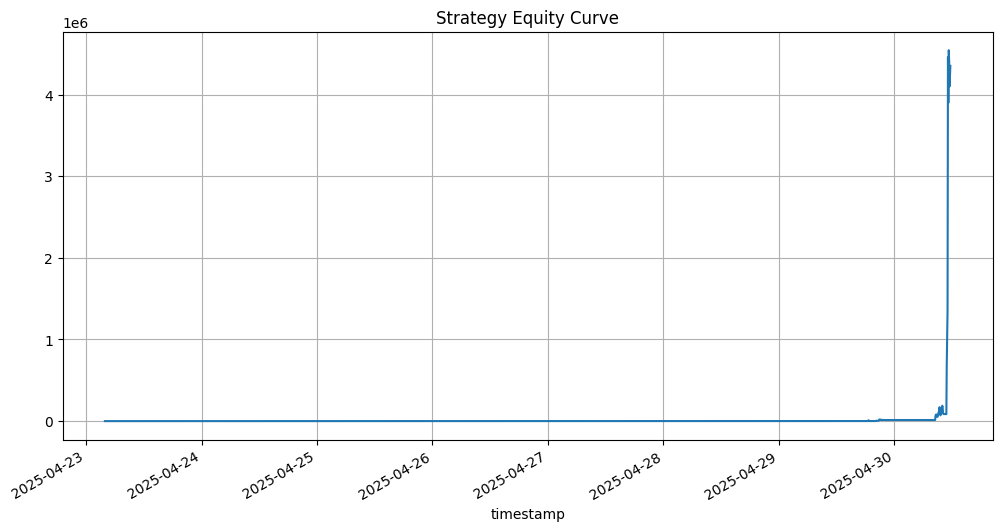

In [15]:
# Calculate and display performance metrics
performance_metrics = calculate_performance_metrics(trades_df, portfolio_df, initial_balance=10)

print("\nPerformance Metrics:")
print(f"Total Trades: {performance_metrics['total_trades']}")
print(f"Win Rate: {performance_metrics['win_rate']:.2f}%")
print(f"Net Profit: ${performance_metrics['net_profit']:.2f}")
print(f"Profit Factor: {performance_metrics['profit_factor']:.2f}")
print(f"Average Trade: ${performance_metrics['avg_trade']:.2f}")
print(f"Max Drawdown: {performance_metrics['max_drawdown_percent']:.2f}%")
print(f"Sharpe Ratio: {performance_metrics['sharpe_ratio']:.2f}")

# Generate and display performance charts
generate_performance_charts(trades_df, portfolio_df, performance_metrics, './strategy_results', 
                          datetime.now().strftime('%Y%m%d_%H%M%S'))

# Display equity curve
plt.figure(figsize=(12, 6))
portfolio_df['equity'].plot(title='Strategy Equity Curve')
plt.grid(True)
plt.show()

In [ ]:
class DynamicDataFetcher(TradingViewDataFetcher):
    def __init__(self, config, username=None, password=None):
        super().__init__(username, password)
        self.config = config
        
    def fetch_all_timeframes(self):
        """Fetch data for all configured timeframes"""
        data = {}
        for timeframe in self.config['timeframes']:
            data[timeframe] = self.fetch_historical_data(
                symbol=self.config['symbol'],
                exchange=self.config['exchange'],
                interval=timeframe,
                days_back=self.config['history_days']
            )
        return data
    
    def update_all_timeframes(self):
        """Update data for all configured timeframes"""
        for timeframe in self.config['timeframes']:
            self.update_data(
                symbol=self.config['symbol'],
                exchange=self.config['exchange'],
                interval=timeframe
            )

In [ ]:
class DynamicDataProcessor:
    def __init__(self, config):
        self.config = config
    
    def calculate_indicators(self, data):
        """Calculate indicators based on configuration"""
        processed_data = {}
        
        # Process H1 data for trend
        h1_data = data['H1'].copy()
        h1_data[f'ema_{self.config["trend_ema_period"]}'] = ta.ema(
            h1_data['close'], 
            length=self.config['trend_ema_period']
        )
        h1_data['trend_bias'] = np.where(
            h1_data['close'] > h1_data[f'ema_{self.config["trend_ema_period"]}'], 
            'bullish', 'bearish'
        )
        
        # Process M5 data for entries and exits
        m5_data = data['M5'].copy()
        
        # Calculate EMA for entry
        m5_data[f'ema_{self.config["entry_ema_period"]}'] = ta.ema(
            m5_data['close'], 
            length=self.config['entry_ema_period']
        )
        
        # Calculate RSI
        m5_data['rsi'] = ta.rsi(m5_data['close'], length=self.config['rsi_period'])
        
        # Calculate MACD
        macd = ta.macd(
            m5_data['close'], 
            fast=self.config['macd_fast'], 
            slow=self.config['macd_slow'], 
            signal=self.config['macd_signal']
        )
        m5_data = m5_data.join(macd)
        
        processed_data['H1'] = h1_data
        processed_data['M5'] = m5_data
        
        return processed_data
    
    def generate_signals(self, data):
        """Generate trading signals based on processed data"""
        m5_data = data['M5'].copy()
        h1_data = data['H1'].copy()
        
        # Resample H1 trend bias to M5 timeframe
        m5_data['trend_bias'] = h1_data['trend_bias'].reindex(
            m5_data.index, method='ffill'
        )
        
        # Generate signals
        m5_data['signal'] = 'no_signal'
        
        # Long entry conditions
        m5_data.loc[
            (m5_data['trend_bias'] == 'bullish') &
            (m5_data['close'] > m5_data[f'ema_{self.config["entry_ema_period"]}']) &
            (m5_data['rsi'] > self.config['rsi_oversold']),
            'signal'
        ] = 'buy'
        
        # Short entry conditions
        m5_data.loc[
            (m5_data['trend_bias'] == 'bearish') &
            (m5_data['close'] < m5_data[f'ema_{self.config["entry_ema_period"]}']) &
            (m5_data['rsi'] < self.config['rsi_overbought']),
            'signal'
        ] = 'sell'
        
        # Calculate stop losses
        m5_data['stop_loss_long'] = m5_data['close'] - (
            self.config['stop_loss_pips'] * self.config['pip_value']
        )
        m5_data['stop_loss_short'] = m5_data['close'] + (
            self.config['stop_loss_pips'] * self.config['pip_value']
        )
        
        return m5_data

In [ ]:
# Initialize the data processor
processor = DataProcessor()

# Example of processing cycle
def process_cycle():
    print("Starting data processing cycle...")
    results = processor.get_latest_data()
    
    for timeframe, data in results.items():
        print(f"\nLatest {timeframe} data:")
        if data is not None:
            print(data.tail())

# Run a processing cycle
process_cycle()

# For continuous processing, you could use:
'''
while True:
    process_cycle()
    time.sleep(60)  # Wait 1 minute before next check
'''